In [2]:
import numpy as np
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist['data'].astype(np.float32)  # Shape: (70000, 784)
y = mnist['target'].astype(np.int64)  # Shape: (70000,)

# train (0-60k) and test(60k-70k)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
# prepreocessing
X_train /= 255.0
X_test /= 255.0

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

X_train shape: (60000, 784), y_train shape: (60000,)
X_test shape:  (10000, 784),  y_test shape:  (10000,)


In [3]:
print(X[:5].shape )
# matlab 784 columns hai .that's crazy
print(X[:5])
print(y[:5])

(5, 784)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[5 0 4 1 9]


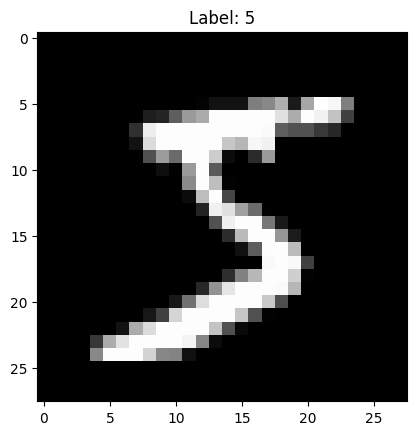

In [4]:
# this is how our data looks like
import matplotlib.pyplot as plt
sample=X_train[0].reshape(28,28)
sample_label=y_train[0];
plt.imshow(sample,cmap='gray')
plt.title(f"Label: {sample_label}")
plt.show('off')
plt.show()

In [7]:
!cat /content/my_nn.py

# -*- coding: utf-8 -*-
"""nn_from_scratch.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1wzII4zFrW8hLP90IS29OzdxQXPRhV1sd
"""

import numpy as np
import matplotlib.pyplot as plt

import numpy as np

# --- Helper Functions ---
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def initialize_parameters(layer_dims):
    parameters = {}
    for i in range(1, len(layer_dims)):
        parameters['W' + str(i)] = np.random.randn(layer_dims[i], layer_dims[i-1]) * np.sqrt(2 / layer_dims[i-1])
        parameters['b' + str(i)] = np.zeros((layer_dims[i], 1))
    return parameters

def forward_propagation(X, parameters):
    cache = {'A0': X}
    A = X
    # Total number of layers (L = 3 for layer_dims [20, 16, 8, 3])
    L = len(parameters) // 2

    # 

epoch 0- cost :1.6067204496529266
epoch 100- cost :1.1422171826982992
epoch 200- cost :1.055411751353212
epoch 300- cost :1.005754259787953
epoch 400- cost :0.9669008099541414
epoch 500- cost :0.9311180378608629
epoch 600- cost :0.8947100995818832
epoch 700- cost :0.8590560611589021
epoch 800- cost :0.8239286078898116
epoch 900- cost :0.7823820445287624


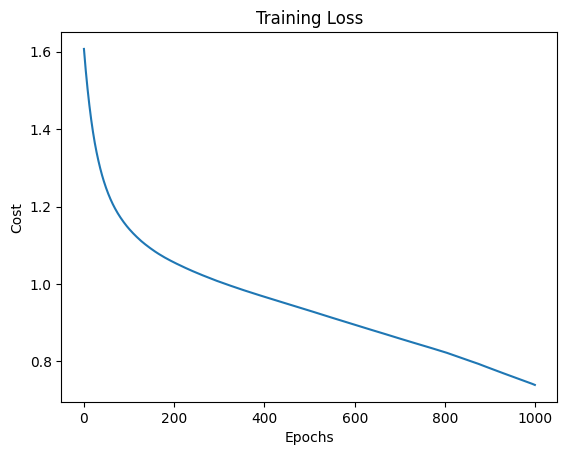

Model Training Accuracy: 73.00%
['X', 'Y', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'acc', 'backward_propagation', 'compute_loss', 'forward_propagation', 'initialize_parameters', 'layer_dims', 'loss_history', 'nn_model', 'np', 'params', 'plt', 'predict', 'preds', 'relu', 'relu_derivative', 'softmax', 'update_parameters']


In [8]:
import my_nn
print(dir(my_nn))

In [9]:
import numpy as np
from my_nn import nn_model,predict
X_train_nn=X_train.T
X_test_nn=X_test.T
Y_train_nn = np.eye(10)[y_train].T
Y_test_nn = np.eye(10)[y_test].T

layer_dims=[784, 128, 64, 10] # last one is output layer(0-9)

params,loss_history=nn_model(X_train_nn,Y_train_nn,layer_dims,epochs=1000,lr=0.1)

pred,accuracy=predict(X_test_nn,Y_test_nn,params)
print(f"test acuracy:{accuracy: .2f}%")

epoch 0- cost :2.372042592285337


KeyboardInterrupt: 

In [10]:
# old mf is taking a hell lot time
import numpy as np
from my_nn import nn_model, predict
X_sub = X_train[:5000].T
Y_sub = np.eye(10)[y_train[:5000]].T
X_test_nn = X_test.T
Y_test_nn = np.eye(10)[y_test].T
layer_dims = [784, 128, 64, 10]
params, loss_history = nn_model(X_sub, Y_sub, layer_dims, epochs=200, lr=0.1)
pred, accuracy = predict(X_test_nn, Y_test_nn, params)
print(f"\nTest Accuracy: {accuracy:.2f}%")


epoch 0- cost :2.356711471813089
epoch 100- cost :0.33107769885382476

Test Accuracy: 90.67%


In [14]:
test_samples=X_test_nn[:,:20]
true_labels=y_test[:20]

predictions, _ = predict(test_samples, Y_test_nn[:, :20], params)
print("Predicted digits:", predictions)
print("Actual digits:   ", true_labels)
print("error array:" ,abs(predictions-true_labels))

Predicted digits: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
Actual digits:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
error array: [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


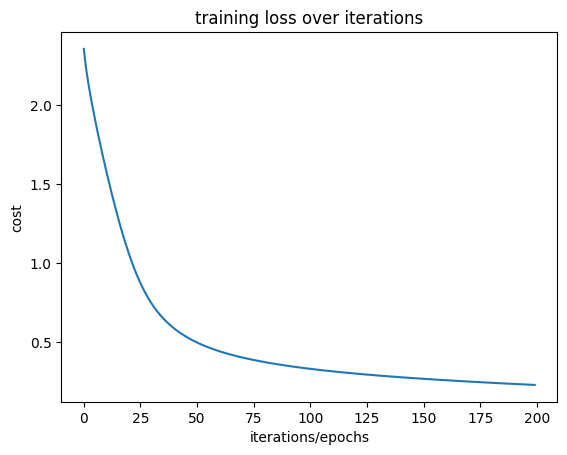

In [15]:
#let's do some plotting
import matplotlib.pyplot  as plt
plt.plot(loss_history)
plt.title("training loss over iterations")
plt.xlabel("iterations/epochs")
plt.ylabel("cost")
plt.show()